DASIT review plasmid titration

Tested in 293Ts, 20k cells/well at 96-well scale \ 
Sparsely labeled eGFP cells \ 
Transfected with minipreps



Reps:
- 2026.06.29: 20k/well (1 reps)
- 2026.07.02: 20k/well (2 reps)


**Load in Functions**

In [1]:
import rushd as rd
import matplotlib
import pandas as pd
import numpy as np
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
from textwrap import wrap
from statannotations.Annotator import Annotator
from pathlib import Path
from scipy.optimize import curve_fit
from scipy.stats import poisson
from matplotlib.ticker import NullLocator

## Load Data from location

In [ ]:
# Set paths to the experiment folder and where to find the data
base_path = rd.datadir/'data'/'attune'/'Mary'

Plates = {'2026.06.29_exp57': ['Plate1'],
          '2026.07.02_exp60': ['Plate1', 'Plate2']
}

exp_path = []
yaml_path = []

for i in Plates:
    for j in Plates[i]:
        exp_path.append(base_path/i/j/'export_singlets')
        yaml_path.append(base_path/i/j/'export_singlets'/'well_metadata.yaml')

output_path = rd.rootdir/'output'/'RevXX_Plasmid_titration'
cache_path = rd.rootdir/'output'/'RevXX_Plasmid_titration'/'data.gzip'

plates_dict = pd.DataFrame({
    'data_path' : [exp for exp in exp_path],
    'yaml_path' : [yaml for yaml in yaml_path]
})

display(plates_dict)

,data_path,yaml_path
0,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...
1,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...
2,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...


**Load in Dataframe**

In [54]:
#Load data
data = pd.DataFrame()
if cache_path.is_file(): data = pd.read_parquet(cache_path)
else:
    channel_list = ['mRuby2-A', 'mRuby2-H','mGL-H','mGL-A', 'iRFP670-A','iRFP670-H', 'FSC-A', 'SSC-A', 'TagBFP-H', 'TagBFP-A']
    data = rd.flow.load_groups_with_metadata(plates_dict,columns=channel_list) #Could add in columns=channel_list here to get specific columns

    # Remove negative values from dataframe
    for c in channel_list: data = data[data[c] > 0]

    # Remove NaN values
    data.dropna(inplace=True)

    # Save data in the cache path for easier loading next time
    data.to_parquet(rd.outfile(cache_path))


In [55]:
data['conds'] = data['reporter'] +'.'+ data['Plasmid'] 
display(data)

,reporter,Plasmid,Date,well,population,FSC-A,SSC-A,mGL-A,mGL-H,iRFP670-A,iRFP670-H,TagBFP-A,TagBFP-H,mRuby2-A,mRuby2-H,conds
4,Controls,0x,2026.06.29.x,A10,Single Cells,334906,233749,192,221,27090,22276,224,236,33194,31478,Controls.0x
5,Controls,0x,2026.06.29.x,A10,Single Cells,312244,486075,234,278,56947,46422,250,264,38434,34859,Controls.0x
13,Controls,0x,2026.06.29.x,A10,Single Cells,342696,192908,126,109,28948,23988,128,91,5470,4393,Controls.0x
15,Controls,0x,2026.06.29.x,A10,Single Cells,307586,246150,141,143,39792,33885,19,61,17936,14709,Controls.0x
17,Controls,0x,2026.06.29.x,A10,Single Cells,371917,571159,240,251,69986,55029,23,78,37551,32062,Controls.0x
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14984256,pKG05003,0.1x,2026.07.02.xx,H9,Single Cells,392454,213801,46,51,76,84,72,79,44,58,pKG05003.0.1x
14984258,pKG05003,0.1x,2026.07.02.xx,H9,Single Cells,192928,203930,21,65,212,179,66,70,33,123,pKG05003.0.1x
14984260,pKG05003,0.1x,2026.07.02.xx,H9,Single Cells,293963,267327,36,46,100,84,54,48,133,81,pKG05003.0.1x
14984266,pKG05003,0.1x,2026.07.02.xx,H9,Single Cells,436866,377209,185,79,275,284,6,84,49,57,pKG05003.0.1x


c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_ke

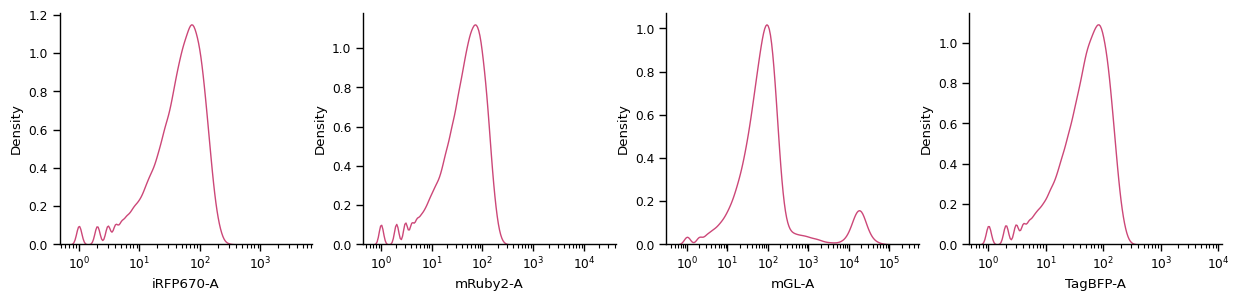

In [ ]:
# Grab the untransfected data
untransfected = data[(data['reporter'] == 'Untransfected')]

**Set gates for FPs**

In [70]:
Plasmid_conds_2 = ['0.1x','0.5x','1x',]
# Set gates for data analysis

# Or use the percentile gating
iRFP_gate_quantile = untransfected['iRFP670-A'].quantile(0.99)
mRuby2_gate_quantile = untransfected['mRuby2-A'].quantile(0.99)
TagBFP_gate_quantile = untransfected['TagBFP-A'].quantile(0.99)
display(iRFP_gate_quantile)
display(mRuby2_gate_quantile)
display(TagBFP_gate_quantile)
eGFP_gate = 3000
mRuby_gate = 1000

# # Gating on co-transfection marker
data_gated = data[data['iRFP670-A'] > iRFP_gate_quantile]
data_eGFP = data[data['mGL-A'] > eGFP_gate]

189.0

182.0

208.0

## Histograms of iRFP

In [83]:
sns.set_context('paper')

c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_ke

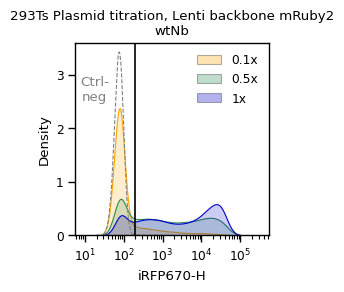

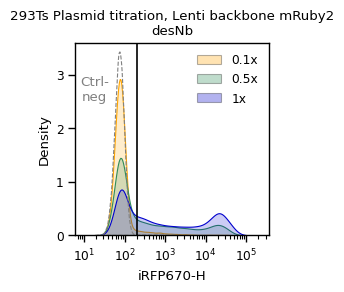

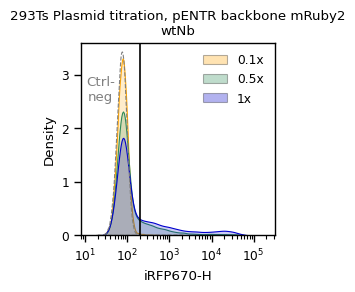

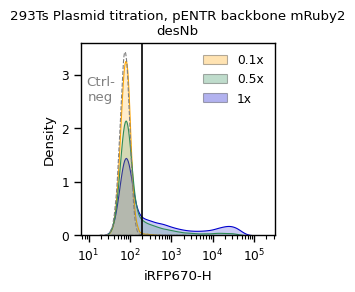

In [ ]:
order = ['pKG05003', 'pKG05002','pKG04934', 'pKG04935']

label_map = {
    'pKG05002':'Lenti backbone mRuby2\ndesNb',
    'pKG05003':'Lenti backbone mRuby2\nwtNb',
    'pKG04437': 'Lenti backbone TagBFP\nwtNb',
    'pKG04440': 'Lenti backbone TagBFP\ndesNb',
    'pKG04934': 'pENTR backbone mRuby2\nwtNb',
    'pKG04935': 'pENTR backbone mRuby2\ndesNb',
    'pKG04405': 'pENTR backbone TagBFP\ndesb',
    'pKG04406': 'pENTR backbone TagBFP\nwtNb'
}

for plasmid in order:
    g = plt.figure(figsize=(4,2.5))
    data_new = data[ (data['reporter'] == plasmid)]
    palette = {'0x': 'grey',
            '0.1x': 'orange',
            '0.5x': 'seagreen',
            '1x': 'mediumblue' }
    ax = sns.kdeplot(data_new, x='iRFP670-H',hue='Plasmid',log_scale=True,legend=False,fill=True,common_norm=False,palette=palette, alpha = 0.2)
    sns.kdeplot(untransfected, x='iRFP670-H',hue='Plasmid',log_scale=True,legend=False,fill=True,common_norm=False,palette=palette, alpha = 0, linestyle = '--')
    ax.axvline(x = 200, color='black', linestyle='-')
    ax.annotate('Ctrl-\nneg', (0.1, 0.7), color='grey', xycoords='axes fraction', ha='center')

    # Add custom legend
    from matplotlib.patches import Patch

    legend_elements = [
        Patch(facecolor='orange', alpha = 0.3, edgecolor='black', label='0.1x'),
        Patch(facecolor='seagreen', alpha = 0.3,  edgecolor='black', label='0.5x'),
        Patch(facecolor='mediumblue', alpha = 0.3,  edgecolor='black', label='1x')
    ]

    ax.legend(handles=legend_elements, frameon=False)
    plt.title(f'293Ts Plasmid titration, {label_map[plasmid]}')
    g = g.get_figure()
    title = str(plasmid) + '_iRFP_mRuby2.svg'
    g.savefig(rd.outfile(output_path/title),bbox_inches='tight')

c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_ke

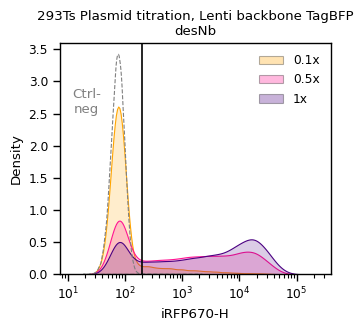

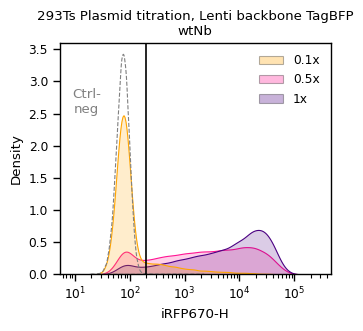

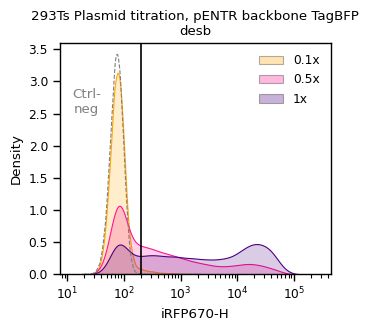

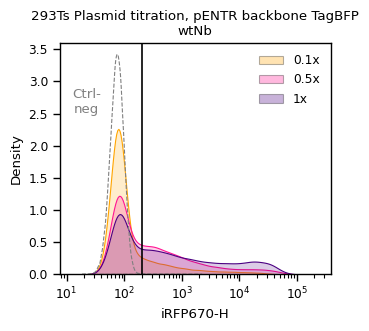

In [20]:
order = ['pKG04440', 'pKG04437','pKG04405', 'pKG04406']

label_map = {
    'pKG05002':'Lenti backbone mRuby2\ndesNb',
    'pKG05003':'Lenti backbone mRuby2\nwtNb',
    'pKG04437': 'Lenti backbone TagBFP\nwtNb',
    'pKG04440': 'Lenti backbone TagBFP\ndesNb',
    'pKG04934': 'pENTR backbone mRuby2\nwtNb',
    'pKG04935': 'pENTR backbone mRuby2\ndesNb',
    'pKG04405': 'pENTR backbone TagBFP\ndesb',
    'pKG04406': 'pENTR backbone TagBFP\nwtNb'
}

for plasmid in order:
    g = plt.figure(figsize=(3.5,3))
    data_new = data[ (data['reporter'] == plasmid)]
    palette = {'0x': 'grey',
            '0.1x': 'orange',
            '0.5x': 'deeppink',
            '1x': 'indigo' }
    ax = sns.kdeplot(data_new, x='iRFP670-H',hue='Plasmid',log_scale=True,legend=False,fill=True,common_norm=False,palette=palette, alpha = 0.2)
    sns.kdeplot(untransfected, x='iRFP670-H',hue='Plasmid',log_scale=True,legend=False,fill=True,common_norm=False,palette=palette, alpha = 0, linestyle = '--')
    ax.axvline(x = 200, color='black', linestyle='-')
    ax.annotate('Ctrl-\nneg', (0.1, 0.7), color='grey', xycoords='axes fraction', ha='center')

    # Add custom legend
    from matplotlib.patches import Patch

    legend_elements = [
        Patch(facecolor='orange', alpha = 0.3, edgecolor='black', label='0.1x'),
        Patch(facecolor='deeppink', alpha = 0.3,  edgecolor='black', label='0.5x'),
        Patch(facecolor='indigo', alpha = 0.3,  edgecolor='black', label='1x')
    ]

    ax.legend(handles=legend_elements, frameon=False)
    plt.title(f'293Ts Plasmid titration, {label_map[plasmid]}')
    g = g.get_figure()
    title = str(plasmid) + '_iRFP_tagBFP.svg'
    g.savefig(rd.outfile(output_path/title),bbox_inches='tight')

## Gating for FP+ cells

In [71]:
mRuby2_gated = data[data['mRuby2-A'] > mRuby2_gate_quantile].copy()
Double_gated = mRuby2_gated[mRuby2_gated['iRFP670-A'] > iRFP_gate_quantile].copy() 
TagBFP_gated = data[data['TagBFP-A'] > TagBFP_gate_quantile].copy()
Double_gated_tag = TagBFP_gated[TagBFP_gated['iRFP670-A'] > iRFP_gate_quantile].copy() 

In [72]:
mRuby2_gated['eGFP_cat'] = np.where(mRuby2_gated['mGL-A'] > eGFP_gate, 'eGFP+', 'eGFP-') 
TagBFP_gated['eGFP_cat'] = np.where(TagBFP_gated['mGL-A'] > eGFP_gate, 'eGFP+', 'eGFP-') 

In [73]:
well_group = ['conds']
count_df = TagBFP_gated.groupby(['conds', 'Date','eGFP_cat'])[
    'FSC-A'].count().unstack(fill_value=0).stack().rename('count')
percent_small_data_1_TagBFP = (count_df*100/count_df.groupby(well_group ).transform('sum')).reset_index(name='percent')
count_small_data_1_TagBFP = count_df.reset_index()
display(percent_small_data_1_TagBFP)

,conds,Date,eGFP_cat,percent
0,Controls.0x,2026.06.29.x,eGFP+,9.088467
1,Controls.0x,2026.06.29.x,eGFP-,90.911533
2,Untransfected.0x,2026.06.29.x,eGFP+,3.298471
3,Untransfected.0x,2026.06.29.x,eGFP-,72.727273
4,Untransfected.0x,2026.07.02.x,eGFP+,1.448109
...,...,...,...,...
147,pKG05003.1x,2026.06.29.x,eGFP-,40.355227
148,pKG05003.1x,2026.07.02.x,eGFP+,2.296375
149,pKG05003.1x,2026.07.02.x,eGFP-,34.433425
150,pKG05003.1x,2026.07.02.xx,eGFP+,1.304666


In [74]:
well_group = ['conds']
count_df = mRuby2_gated.groupby(['conds', 'Date','eGFP_cat'])[
    'FSC-A'].count().unstack(fill_value=0).stack().rename('count')
percent_small_data_1_mRuby2 = (count_df*100/count_df.groupby(well_group ).transform('sum')).reset_index(name='percent')
count_small_data_1_mRuby2 = count_df.reset_index()
display(percent_small_data_1_mRuby2)

,conds,Date,eGFP_cat,percent
0,Controls.0x,2026.06.29.x,eGFP+,7.508532
1,Controls.0x,2026.06.29.x,eGFP-,92.491468
2,Untransfected.0x,2026.06.29.x,eGFP+,5.742412
3,Untransfected.0x,2026.06.29.x,eGFP-,73.010664
4,Untransfected.0x,2026.07.02.x,eGFP+,1.230517
...,...,...,...,...
147,pKG05003.1x,2026.06.29.x,eGFP-,29.217716
148,pKG05003.1x,2026.07.02.x,eGFP+,2.732937
149,pKG05003.1x,2026.07.02.x,eGFP-,31.585489
150,pKG05003.1x,2026.07.02.xx,eGFP+,2.719812


## Bar plots

c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


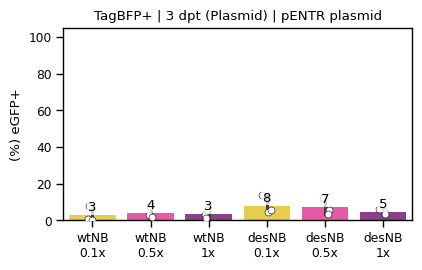

In [ ]:
# General plotting params
x = 'conds'
y = 'percent'

# Conditions
order = [ 'pKG04406.0.1x','pKG04406.0.5x','pKG04406.1x', 'pKG04405.0.1x', 'pKG04405.0.5x', 'pKG04405.1x']
eGFP_cat = 'eGFP+'
color = 'limegreen'

df = percent_small_data_1_TagBFP.loc[percent_small_data_1_TagBFP['eGFP_cat'] == eGFP_cat]
palette = {
    'pKG04405.0.1x': 'orange', 
    'pKG04405.0.5x': 'deeppink', 
    'pKG04405.1x': 'purple',
    'pKG04406.0.1x': 'gold', 
    'pKG04406.0.5x': 'deeppink', 
    'pKG04406.1x': 'purple'
}

fig, ax = plt.subplots(1, 1, figsize=(4.5, 2.5))

# Plot hyperP percent of all cells
sns.barplot(
    ax=ax, data=df,
    x=x, y=y,
    order=order,
    palette=palette,
    alpha=0.8)

sns.stripplot(
    ax=ax, data=df,
    x=x, y=y,
    order=order,
    dodge=True,
    color='white', size=5,
    edgecolor='black', linewidth=0.4,)


lmap = {
    'pKG04406.0.1x': 'wtNB\n0.1x', 
    'pKG04406.0.5x': 'wtNB\n0.5x', 
    'pKG04406.1x': 'wtNB\n1x',
    'pKG04405.0.1x': 'desNB\n0.1x', 
    'pKG04405.0.5x': 'desNB\n0.5x', 
    'pKG04405.1x': 'desNB\n1x'
}

ax.set_xticklabels([lmap[cond] for cond in order])
ax.set_ylim((0, 105))
ax.yaxis.set_label_text('(%) eGFP+')
ax.set_title('TagBFP+ | 3 dpt (Plasmid) | pENTR plasmid')
ax.set_xlabel('')

# Add barplot labels
for sub_ax in plt.gcf().get_axes():
    for i in sub_ax.containers:
        bar_labels = sub_ax.bar_label(i, fmt='%0.0f', padding=1)
        for label in bar_labels:
            label.set_bbox(dict(facecolor='white', alpha=0.75, linewidth=0, pad=1))    

# plt.savefig(figpath + 'modRNA_1dpt_selectivity.svg', bbox_inches='tight')

c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


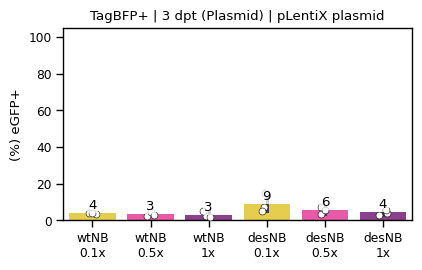

In [75]:
# General plotting params
x = 'conds'
y = 'percent'

# Conditions
order = [ 'pKG04437.0.1x','pKG04437.0.5x','pKG04437.1x', 'pKG04440.0.1x', 'pKG04440.0.5x', 'pKG04440.1x']
eGFP_cat = 'eGFP+'
color = 'limegreen'

df = percent_small_data_1_TagBFP.loc[percent_small_data_1_TagBFP['eGFP_cat'] == eGFP_cat]
palette = {
    'pKG04437.0.1x': 'gold', 
    'pKG04437.0.5x': 'deeppink', 
    'pKG04437.1x': 'purple',
    'pKG04440.0.1x': 'gold', 
    'pKG04440.0.5x': 'deeppink', 
    'pKG04440.1x': 'purple'
}

fig, ax = plt.subplots(1, 1, figsize=(4.5, 2.5))

# Plot hyperP percent of all cells
sns.barplot(
    ax=ax, data=df,
    x=x, y=y,
    order=order,
    palette=palette,
    alpha=0.8)

sns.stripplot(
    ax=ax, data=df,
    x=x, y=y,
    order=order,
    dodge=True,
    color='white', size=5,
    edgecolor='black', linewidth=0.4,)


lmap = {
    'pKG04437.0.1x': 'wtNB\n0.1x', 
    'pKG04437.0.5x': 'wtNB\n0.5x', 
    'pKG04437.1x': 'wtNB\n1x',
    'pKG04440.0.1x': 'desNB\n0.1x', 
    'pKG04440.0.5x': 'desNB\n0.5x', 
    'pKG04440.1x': 'desNB\n1x'
}

ax.set_xticklabels([lmap[cond] for cond in order])
ax.set_ylim((0, 105))
ax.yaxis.set_label_text('(%) eGFP+')
ax.set_title('TagBFP+ | 3 dpt (Plasmid) | pLentiX plasmid')
ax.set_xlabel('')

# Add barplot labels
for sub_ax in plt.gcf().get_axes():
    for i in sub_ax.containers:
        bar_labels = sub_ax.bar_label(i, fmt='%0.0f', padding=1)
        for label in bar_labels:
            label.set_bbox(dict(facecolor='white', alpha=0.75, linewidth=0, pad=1))    

# plt.savefig(figpath + 'modRNA_1dpt_selectivity.svg', bbox_inches='tight')

c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


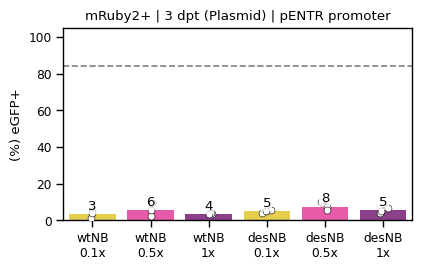

In [76]:
# General plotting params
x = 'conds'
y = 'percent'

# Conditions
order = ['pKG04934.0.1x', 'pKG04934.0.5x', 'pKG04934.1x', 'pKG04935.0.1x','pKG04935.0.5x','pKG04935.1x']
eGFP_cat = 'eGFP+'
color = 'limegreen'

df = percent_small_data_1_mRuby2.loc[percent_small_data_1_mRuby2['eGFP_cat'] == eGFP_cat]
palette = {
    'pKG04934.0.1x': 'gold', 
    'pKG04934.0.5x': 'deeppink', 
    'pKG04934.1x': 'purple',
    'pKG04935.0.1x': 'gold', 
    'pKG04935.0.5x': 'deeppink', 
    'pKG04935.1x': 'purple'
}

fig, ax = plt.subplots(1, 1, figsize=(4.5, 2.5))

# Plot hyperP percent of all cells
sns.barplot(
    ax=ax, data=df,
    x=x, y=y,
    order=order,
    palette=palette,
    alpha=0.8)

sns.stripplot(
    ax=ax, data=df,
    x=x, y=y,
    order=order,
    dodge=True,
    color='white', size=5,
    edgecolor='black', linewidth=0.4,)


lmap = {
    'pKG04935.0.1x': 'desNB\n0.1x', 
    'pKG04935.0.5x': 'desNB\n0.5x', 
    'pKG04935.1x': 'desNB\n1x',
    'pKG04934.0.1x': 'wtNB\n0.1x', 
    'pKG04934.0.5x': 'wtNB\n0.5x', 
    'pKG04934.1x': 'wtNB\n1x'
}
plt.axhline(y=84, color='grey', linestyle= '--')
ax.set_xticklabels([lmap[cond] for cond in order])
ax.set_ylim((0, 105))
ax.yaxis.set_label_text('(%) eGFP+')
ax.set_title('mRuby2+ | 3 dpt (Plasmid) | pENTR promoter')
ax.set_xlabel('')


# Add barplot labels
for sub_ax in plt.gcf().get_axes():
    for i in sub_ax.containers:
        bar_labels = sub_ax.bar_label(i, fmt='%0.0f', padding=1)
        for label in bar_labels:
            label.set_bbox(dict(facecolor='white', alpha=0.75, linewidth=0, pad=1))    
 
plottitle = 'Plasmid_titration.svg'
plt.savefig(rd.outfile(output_path/plottitle),bbox_inches='tight')

c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


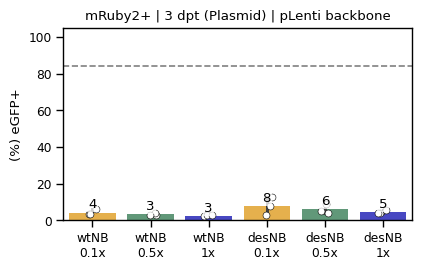

In [77]:
# General plotting params
x = 'conds'
y = 'percent'

# Conditions
order = ['pKG05003.0.1x', 'pKG05003.0.5x', 'pKG05003.1x', 'pKG05002.0.1x','pKG05002.0.5x','pKG05002.1x']
eGFP_cat = 'eGFP+'
color = 'limegreen'

df = percent_small_data_1_mRuby2.loc[percent_small_data_1_mRuby2['eGFP_cat'] == eGFP_cat]
palette = {
    'pKG05003.0.1x': 'orange', 
    'pKG05003.0.5x': 'seagreen', 
    'pKG05003.1x': 'mediumblue',
    'pKG05002.0.1x': 'orange', 
    'pKG05002.0.5x': 'seagreen', 
    'pKG05002.1x': 'mediumblue'
}

fig, ax = plt.subplots(1, 1, figsize=(4.5, 2.5))

# Plot hyperP percent of all cells
sns.barplot(
    ax=ax, data=df,
    x=x, y=y,
    order=order,
    palette=palette,
    alpha=0.8)

sns.stripplot(
    ax=ax, data=df,
    x=x, y=y,
    order=order,
    dodge=True,
    color='white', size=5,
    edgecolor='black', linewidth=0.4,)


lmap = {
    'pKG05003.0.1x': 'wtNB\n0.1x', 
    'pKG05003.0.5x': 'wtNB\n0.5x', 
    'pKG05003.1x': 'wtNB\n1x',
    'pKG05002.0.1x': 'desNB\n0.1x', 
    'pKG05002.0.5x': 'desNB\n0.5x', 
    'pKG05002.1x': 'desNB\n1x'
}
plt.axhline(y=84, color='grey', linestyle= '--')
ax.set_xticklabels([lmap[cond] for cond in order])
ax.set_ylim((0, 105))
ax.yaxis.set_label_text('(%) eGFP+')
ax.set_title('mRuby2+ | 3 dpt (Plasmid) | pLenti backbone')
ax.set_xlabel('')


# Add barplot labels
for sub_ax in plt.gcf().get_axes():
    for i in sub_ax.containers:
        bar_labels = sub_ax.bar_label(i, fmt='%0.0f', padding=1)
        for label in bar_labels:
            label.set_bbox(dict(facecolor='white', alpha=0.75, linewidth=0, pad=1))    
 
plottitle = 'Plasmid_titration.svg'
plt.savefig(rd.outfile(output_path/plottitle),bbox_inches='tight')

## Scatter Plots

C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_8632\2699855555.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), 10000), random_state=1))
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a 

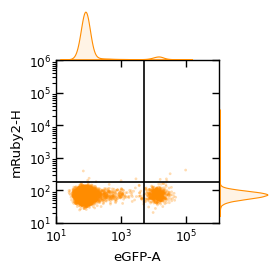

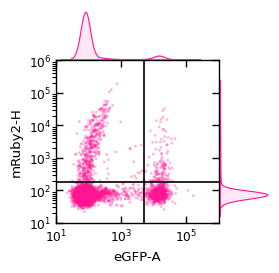

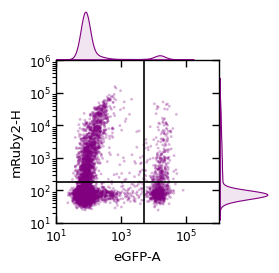

In [ ]:
# General plotting params
y = "mRuby2-H"
x = "mGL-H"
hue = "Plasmid"
hue_order = Plasmid_conds_2

# Conditions
palette = {
    '0.1x': 'orange', 
    '0.5x': 'seagreen', 
    '1x': 'mediumblue'
}
for amount in Plasmid_conds_2:
    # Conditions
    data_now = data[
        (data['reporter'] == 'pKG04935') & (data['Plasmid'] == amount)
    ]

    # only look at no selection and iRFP+ infected
    small_data = pd.concat([data_now])

    # ----------------------------------------
    # Sample max 10,000 points per condition
    # ----------------------------------------
    small_data_sampled = (
        small_data
        .groupby(hue, group_keys=False)
        .apply(lambda x: x.sample(min(len(x), 10000), random_state=1))
    )

    # definitions for the axes
    left, width = 0.1, 0.65
    bottom, height = 0.1, 0.65
    spacing = 0.005

    rect_scatter = [left, bottom, width, height]
    rect_histx = [left, bottom + height + spacing, width, 0.2]
    rect_histy = [left + width + spacing, bottom, 0.2, height]

    # Set up figure
    fig = plt.figure(figsize=(2.5, 2.5))

    ax_scatter = plt.axes(rect_scatter)
    ax_scatter.tick_params(direction="in", top=True, right=True)

    ax_histx = plt.axes(rect_histx)
    ax_histx.set_axis_off()

    ax_histy = plt.axes(rect_histy)
    ax_histy.set_axis_off()

    # Set limits
    mRuby2_lim = (10, 1e6)
    mCherry_lim = (10, 1e6)

    ylim = mRuby2_lim
    xlim = mCherry_lim

    ax_scatter.set_xlim(xlim)
    ax_scatter.set_ylim(ylim)

    ax_histx.set_xlim(xlim)
    ax_histy.set_ylim(ylim)

    # Scatter plot
    sns.scatterplot(
        ax=ax_scatter,
        data=small_data_sampled,
        x=x,
        y=y,
        hue=hue,
        hue_order=hue_order,
        palette=palette,
        s=4,
        alpha=0.3,
        linewidth=0,
        legend=False
    )

    ax_scatter.set_xscale('log')
    ax_scatter.set_yscale('log')

    # Marginal KDEs
    sns.kdeplot(
        ax=ax_histx,
        data=small_data,
        x=x,
        hue=hue,
        hue_order=hue_order,
        alpha=0.1,
        palette=palette,
        log_scale=True,
        fill=True,
        common_norm=False,
        legend=False,
    )

    sns.kdeplot(
        ax=ax_histy,
        data=small_data,
        y=y,
        hue=hue,
        hue_order=hue_order,
        alpha=0.1,
        palette=palette,
        log_scale=True,
        fill=True,
        common_norm=False,
        legend=False,
    )

    # Thresholds
    ax_scatter.axhline(mRuby2_gate_quantile, 0, 1, color='black')
    ax_scatter.axvline(eGFP_gate, 0, 1, color='black')
    ax_scatter.set_xlabel('eGFP-A')

    fig.tight_layout()

    plottitle = str(amount) + 'pKG04935_height.svg'
    plt.savefig(rd.outfile(output_path/plottitle), bbox_inches='tight')

C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_8632\2847336057.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), 10000), random_state=1))
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a 

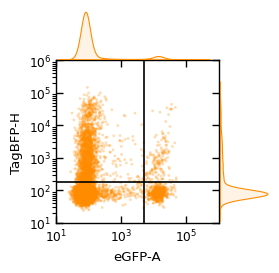

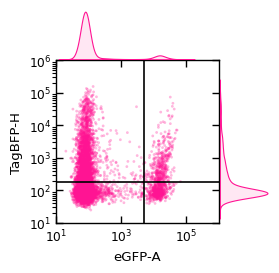

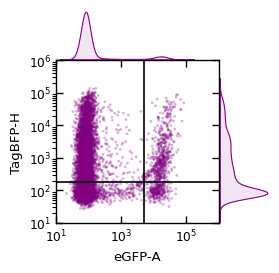

In [49]:
# General plotting params
y = "TagBFP-H"
x = "mGL-H"
hue = "Plasmid"
hue_order = Plasmid_conds_2

# Conditions
palette = {
    '0.1x': 'darkorange', 
    '0.5x': 'deeppink', 
    '1x': 'purple'
}
for amount in Plasmid_conds_2:
    # Conditions
    data_now = data[
        (data['reporter'] == 'pKG04406') & (data['Plasmid'] == amount)
    ]

    # only look at no selection and iRFP+ infected
    small_data = pd.concat([data_now])

    # ----------------------------------------
    # Sample max 10,000 points per condition
    # ----------------------------------------
    small_data_sampled = (
        small_data
        .groupby(hue, group_keys=False)
        .apply(lambda x: x.sample(min(len(x), 10000), random_state=1))
    )

    # definitions for the axes
    left, width = 0.1, 0.65
    bottom, height = 0.1, 0.65
    spacing = 0.005

    rect_scatter = [left, bottom, width, height]
    rect_histx = [left, bottom + height + spacing, width, 0.2]
    rect_histy = [left + width + spacing, bottom, 0.2, height]

    # Set up figure
    fig = plt.figure(figsize=(2.5, 2.5))

    ax_scatter = plt.axes(rect_scatter)
    ax_scatter.tick_params(direction="in", top=True, right=True)

    ax_histx = plt.axes(rect_histx)
    ax_histx.set_axis_off()

    ax_histy = plt.axes(rect_histy)
    ax_histy.set_axis_off()

    # Set limits
    mRuby2_lim = (10, 1e6)
    mCherry_lim = (10, 1e6)

    ylim = mRuby2_lim
    xlim = mCherry_lim

    ax_scatter.set_xlim(xlim)
    ax_scatter.set_ylim(ylim)

    ax_histx.set_xlim(xlim)
    ax_histy.set_ylim(ylim)

    # Scatter plot
    sns.scatterplot(
        ax=ax_scatter,
        data=small_data_sampled,
        x=x,
        y=y,
        hue=hue,
        hue_order=hue_order,
        palette=palette,
        s=4,
        alpha=0.3,
        linewidth=0,
        legend=False
    )

    ax_scatter.set_xscale('log')
    ax_scatter.set_yscale('log')

    # Marginal KDEs
    sns.kdeplot(
        ax=ax_histx,
        data=small_data,
        x=x,
        hue=hue,
        hue_order=hue_order,
        alpha=0.1,
        palette=palette,
        log_scale=True,
        fill=True,
        common_norm=False,
        legend=False,
    )

    sns.kdeplot(
        ax=ax_histy,
        data=small_data,
        y=y,
        hue=hue,
        hue_order=hue_order,
        alpha=0.1,
        palette=palette,
        log_scale=True,
        fill=True,
        common_norm=False,
        legend=False,
    )

    # Thresholds
    ax_scatter.axhline(mRuby2_gate_quantile, 0, 1, color='black')
    ax_scatter.axvline(eGFP_gate, 0, 1, color='black')
    ax_scatter.set_xlabel('eGFP-A')

    fig.tight_layout()

    plottitle = str(amount) + 'pKG04406_height.svg'
    plt.savefig(rd.outfile(output_path/plottitle), bbox_inches='tight')

## Small Contours

c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\chemegrad202\AppData\Local\Programs

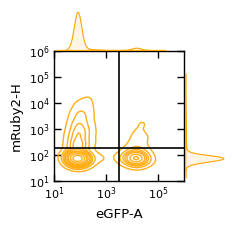

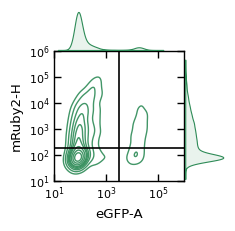

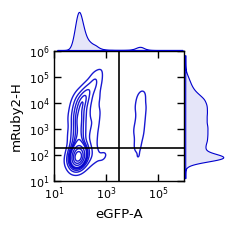

In [88]:
# General plotting params
y = "mRuby2-H"
x = "mGL-H"
hue = "Plasmid"
hue_order = Plasmid_conds_2

# Conditions
palette = {
    '0.1x': 'orange', 
    '0.5x': 'seagreen', 
    '1x': 'mediumblue'
}

for amount in Plasmid_conds_2:

        # Conditions
    data_now = data[
        (data['reporter'] == 'pKG05003') &
        (data['Plasmid'] == amount)
    ]

    small_data = pd.concat([data_now])

    # ----------------------------------------------------
    # Define bottom-left quadrant:
    # below BOTH gates
    # ----------------------------------------------------
    bottom_left = small_data[
        (small_data[x] < eGFP_gate) &
        (small_data[y] < mRuby2_gate_quantile)
    ]

    # Everything else
    not_bottom_left = small_data[
        ~(
            (small_data[x] < eGFP_gate) &
            (small_data[y] < mRuby2_gate_quantile)
        )
    ]

    # ----------------------------------------------------
    # Sample:
    # 1000 from bottom-left
    # 10000 from everything else
    # ----------------------------------------------------
    sampled_bottom_left = bottom_left.sample(
        min(len(bottom_left), 5000),
        random_state=1
    )

    sampled_not_bottom_left = not_bottom_left.sample(
        min(len(not_bottom_left), 5000),
        random_state=1
    )

    # Combine sampled data
    small_data_sampled = pd.concat([
        sampled_bottom_left,
        sampled_not_bottom_left
    ])

    # definitions for the axes
    left, width = 0.1, 0.65
    bottom, height = 0.1, 0.65
    spacing = 0.005

    rect_scatter = [left, bottom, width, height]
    rect_histx = [left, bottom + height + spacing, width, 0.2]
    rect_histy = [left + width + spacing, bottom, 0.2, height]

    # Set up figure
    fig = plt.figure(figsize=(2, 2))

    ax_scatter = plt.axes(rect_scatter)
    ax_scatter.tick_params(direction="in", top=True, right=True, labelsize=8)

    ax_histx = plt.axes(rect_histx)
    ax_histx.set_axis_off()

    ax_histy = plt.axes(rect_histy)
    ax_histy.set_axis_off()

    # Set limits
    mRuby2_lim = (10, 1e6)
    mCherry_lim = (10, 1e6)

    ylim = mRuby2_lim
    xlim = mCherry_lim

    ax_scatter.set_xlim(xlim)
    ax_scatter.set_ylim(ylim)

    ax_histx.set_xlim(xlim)
    ax_histy.set_ylim(ylim)

    # ----------------------------------------------------
    # Contour plot
    # ----------------------------------------------------
    sns.kdeplot(
        ax=ax_scatter,
        data=small_data_sampled,
        x=x,
        y=y,
        hue=hue,
        hue_order=hue_order,
        palette=palette,
        fill=False,
        levels=10,
        thresh=0.05,
        alpha=0.9,
        linewidths=1,
        legend=False,
        log_scale=True
    )

    ax_scatter.set_xscale('log')
    ax_scatter.set_yscale('log')



    # Remove minor ticks on the y-axis
    ax_scatter.yaxis.set_minor_locator(NullLocator())
    ax_scatter.tick_params(axis='y', which='minor', left=False, right=False)

    # Marginal KDEs
    sns.kdeplot(
        ax=ax_histx,
        data=small_data,
        x=x,
        hue=hue,
        hue_order=hue_order,
        alpha=0.1,
        palette=palette,
        log_scale=True,
        fill=True,
        common_norm=False,
        legend=False,
    )

    sns.kdeplot(
        ax=ax_histy,
        data=small_data,
        y=y,
        hue=hue,
        hue_order=hue_order,
        alpha=0.1,
        palette=palette,
        log_scale=True,
        fill=True,
        common_norm=False,
        legend=False,
    )

    # Thresholds
    ax_scatter.axhline(mRuby2_gate_quantile, 0, 1, color='black')
    ax_scatter.axvline(eGFP_gate, 0, 1, color='black')
    ax_scatter.set_xlabel('eGFP-A')

    fig.tight_layout()

    plottitle = str(amount) + 'pKG05003_height.svg'

    plt.savefig(
        rd.outfile(output_path / plottitle),
        bbox_inches='tight'
    )

In [ ]:
# ----------------------------------------------------
# Calculate quadrant percentages for each condition
# ----------------------------------------------------

for amount in Plasmid_conds_2:

    # Filter data
    data_now = data[
        (data['reporter'] == 'pKG04935') &
        (data['Plasmid'] == amount)
    ]

    total_cells = len(data_now)

    # Top-right quadrant
    top_right = data_now[
        (data_now[x] >= eGFP_gate) &
        (data_now[y] >= mRuby2_gate_quantile)
    ]

    # Top-left quadrant
    top_left = data_now[
        (data_now[x] < eGFP_gate) &
        (data_now[y] >= mRuby2_gate_quantile)
    ]

    # Percentages
    top_right_percent = 100 * len(top_right) / total_cells
    top_left_percent = 100 * len(top_left) / total_cells

    print(f"{amount}")
    print(f"  Top-right: {top_right_percent:.2f}%")
    print(f"  Top-left : {top_left_percent:.2f}%")
    print()

0.1x
  Top-right: 0.11%
  Top-left : 0.32%

0.5x
  Top-right: 0.76%
  Top-left : 0.90%

1x
  Top-right: 0.89%
  Top-left : 1.91%



## Histograms

c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_ke

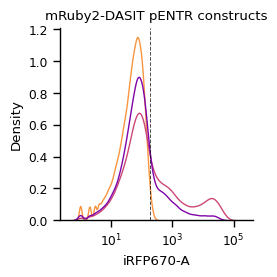

In [33]:
palette = 'plasma'
order = ['pKG04934', 'pKG04935', 'Untransfected']
data_new = data[ (data['reporter'].isin(order))& (data['Plasmid'] == '1x')]
data_now = pd.concat([data_new, untransfected])
g = plt.figure(figsize=(2.5,2.5))

g = custom_hist_plot(data_now, parameters=['iRFP670-A'], hue='reporter', palette=palette, alpha=0,title ='mRuby2-DASIT pENTR constructs', line = iRFP_gate_quantile, legend=False)

c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_ke

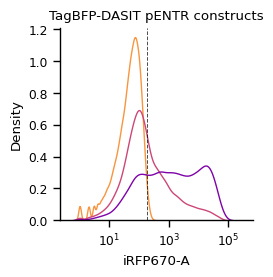

In [32]:
palette = 'plasma'
order = ['pKG04405', 'pKG04406', 'Untransfected']
data_new = data[ (data['reporter'].isin(order))& (data['Plasmid'] == '1x')]
data_now = pd.concat([data_new, untransfected])
g = plt.figure(figsize=(2.5,2.5))

g = custom_hist_plot(data_now, parameters=['iRFP670-A'], hue='reporter', palette=palette, alpha=0,title ='TagBFP-DASIT pENTR constructs', line = iRFP_gate_quantile, legend=False)

c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_ke

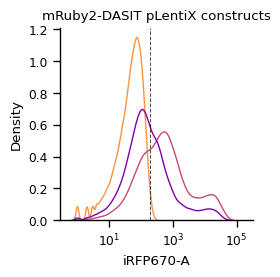

In [34]:
palette = 'plasma'
order = ['pKG05002', 'pKG05003', 'Untransfected']
data_new = data[ (data['reporter'].isin(order))& (data['Plasmid'] == '1x')]
data_now = pd.concat([data_new, untransfected])
g = plt.figure(figsize=(2.5,2.5))

g = custom_hist_plot(data_now, parameters=['iRFP670-A'], hue='reporter', palette=palette, alpha=0,title ='mRuby2-DASIT pLentiX constructs', line = iRFP_gate_quantile, legend=False)

c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_ke

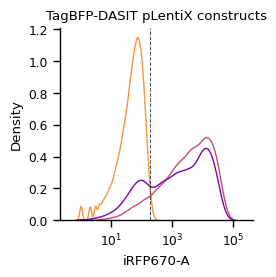

In [35]:
palette = 'plasma'
order = ['pKG04437', 'pKG04440', 'Untransfected']
data_new = data[ (data['reporter'].isin(order))& (data['Plasmid'] == '1x')]
data_now = pd.concat([data_new, untransfected])
g = plt.figure(figsize=(2.5,2.5))

g = custom_hist_plot(data_now, parameters=['iRFP670-A'], hue='reporter', palette=palette, alpha=0,title ='TagBFP-DASIT pLentiX constructs', line = iRFP_gate_quantile, legend=False)

c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_ke

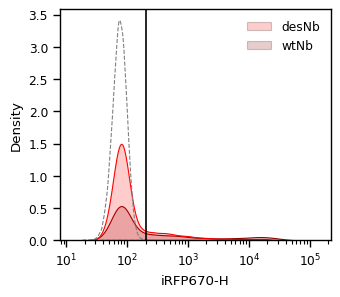

In [37]:
g = plt.figure(figsize=(3.5,3))
palette = {'Untransfected': 'grey',
           'pKG04934': 'red',
           'pKG04935': 'darkred'}
order = ['pKG04934', 'pKG04935', 'Untransfected']
data_new = data[ (data['reporter'].isin(order))& (data['Plasmid'] == '1x')]
ax = sns.kdeplot(data_new, x='iRFP670-H',hue='reporter',log_scale=True,legend=True,fill=True,common_norm=True,palette=palette, alpha = 0.2)
sns.kdeplot(untransfected, x='iRFP670-H',hue='reporter',log_scale=True,legend=False,fill=True,common_norm=True,palette=palette, alpha = 0, linestyle = '--')
ax.axvline(x = 200, color='black', linestyle='-')

# Add custom legend
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor='red', alpha = 0.2, edgecolor='black', label='desNb'),
    Patch(facecolor='darkred', alpha = 0.2,  edgecolor='black', label='wtNb')
]

ax.legend(handles=legend_elements, frameon=False)

g = g.get_figure()
g.savefig(rd.outfile(output_path/'plasmid_titration_hist.svg'),bbox_inches='tight')

c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_ke

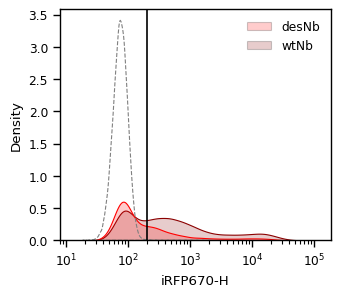

In [38]:
g = plt.figure(figsize=(3.5,3))
palette = {'Untransfected': 'grey',
           'pKG05002': 'red',
           'pKG05003': 'darkred'}
order = ['pKG05002', 'pKG05003', 'Untransfected']
data_new = data[ (data['reporter'].isin(order))& (data['Plasmid'] == '1x')]
ax = sns.kdeplot(data_new, x='iRFP670-H',hue='reporter',log_scale=True,legend=True,fill=True,common_norm=True,palette=palette, alpha = 0.2)
sns.kdeplot(untransfected, x='iRFP670-H',hue='reporter',log_scale=True,legend=False,fill=True,common_norm=True,palette=palette, alpha = 0, linestyle = '--')
ax.axvline(x = 200, color='black', linestyle='-')

# Add custom legend
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor='red', alpha = 0.2, edgecolor='black', label='desNb'),
    Patch(facecolor='darkred', alpha = 0.2,  edgecolor='black', label='wtNb')
]

ax.legend(handles=legend_elements, frameon=False)

g = g.get_figure()
g.savefig(rd.outfile(output_path/'plasmid_titration_hist.svg'),bbox_inches='tight')

c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_ke

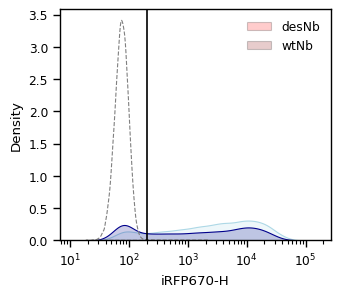

In [41]:
g = plt.figure(figsize=(3.5,3))
palette = {'Untransfected': 'grey',
           'pKG04437': 'lightblue',
           'pKG04440': 'darkblue'}
order = ['pKG04437', 'pKG04440', 'Untransfected']
data_new = data[ (data['reporter'].isin(order))& (data['Plasmid'] == '1x')]
ax = sns.kdeplot(data_new, x='iRFP670-H',hue='reporter',log_scale=True,legend=True,fill=True,common_norm=True,palette=palette, alpha = 0.2)
sns.kdeplot(untransfected, x='iRFP670-H',hue='reporter',log_scale=True,legend=False,fill=True,common_norm=True,palette=palette, alpha = 0, linestyle = '--')
ax.axvline(x = 200, color='black', linestyle='-')

# Add custom legend
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor='red', alpha = 0.2, edgecolor='black', label='desNb'),
    Patch(facecolor='darkred', alpha = 0.2,  edgecolor='black', label='wtNb')
]

ax.legend(handles=legend_elements, frameon=False)

g = g.get_figure()
g.savefig(rd.outfile(output_path/'plasmid_titration_hist.svg'),bbox_inches='tight')